In [128]:
import pandas as pd
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [129]:
df = pd.read_csv('../data/Titanic_dataset.csv', usecols = ['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [130]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [131]:
df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\aryan\AppData\Local\Temp\ipykernel_33012\1728128861.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)


In [132]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [133]:
X = df.iloc[:, 1:]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
X_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


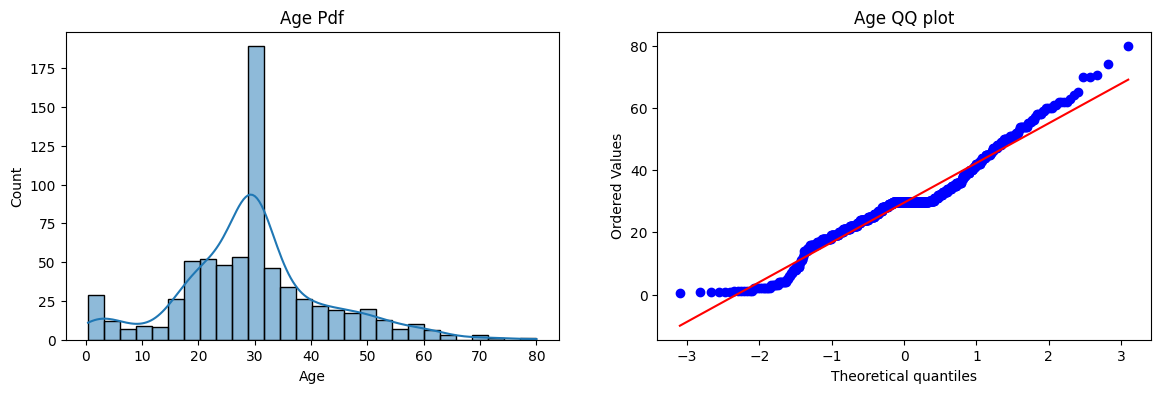

In [135]:
# Checking distribution of data for age feature

plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age Pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ plot')

plt.show()

Text(0.5, 1.0, 'Fare QQ plot')

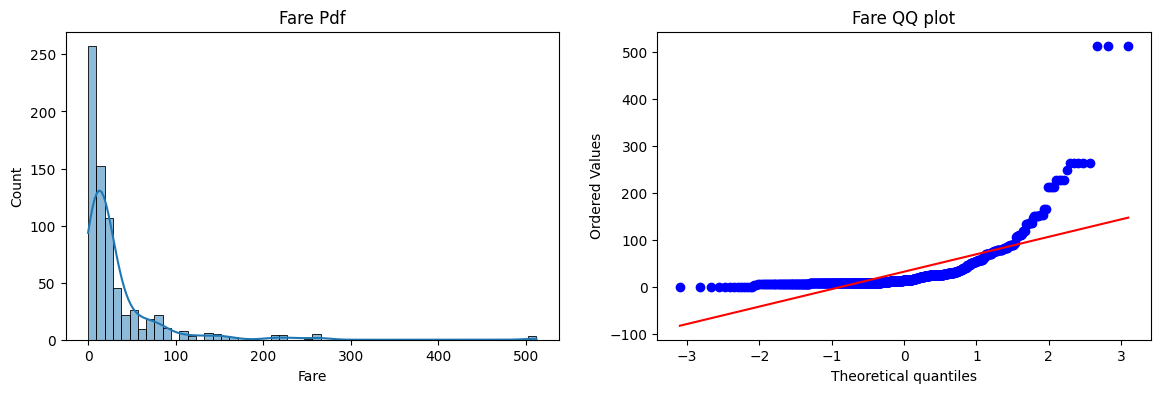

In [136]:
# Checking distribution of data for fare feature

plt.figure(figsize=(14, 4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ plot')

In [137]:
# First training the model without applying mathematical transformations 

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)

acc1 = accuracy_score(pred1, y_test)
acc2 = accuracy_score(pred2, y_test)

print(f'Accuracy (Logistic Reg) = {acc1*100 : .2f}')
print(f'Accuracy (Decision Tree) = {acc2*100 : .2f}')

Accuracy (Logistic Reg) =  64.80
Accuracy (Decision Tree) =  68.16


In [138]:
# Now applying function transformer on both

fn_trf = FunctionTransformer(func=np.log1p) #np.log(x) = logx, np.log1p = log(1 + x)

X_train_transformed = fn_trf.fit_transform(X_train)
X_test_transformed = fn_trf.transform(X_test)

In [139]:
#Training model on transformed data

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train_transformed, y_train)
model2.fit(X_train_transformed, y_train)

pred1 = model1.predict(X_test_transformed)
pred2 = model2.predict(X_test_transformed)

acc1 = accuracy_score(pred1, y_test)
acc2 = accuracy_score(pred2, y_test)

print(f'Accuracy (Logistic Reg) = {acc1*100 : .2f}')
print(f'Accuracy (Decision Tree) = {acc2*100 : .2f}')

Accuracy (Logistic Reg) =  68.16
Accuracy (Decision Tree) =  68.16


In [140]:
# Cross-validating to check if results are true 

X_transformed = fn_trf.fit_transform(X)

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

print('Logistic Reg', np.mean(cross_val_score(model1, X_transformed, y, scoring='accuracy', cv=10)))
print('Decision Tree', np.mean(cross_val_score(model2, X_transformed, y, scoring='accuracy', cv=10)))

Logistic Reg 0.678027465667915
Decision Tree 0.6599500624219725


In [141]:
# Logistic Reg accuracy improved due to Log transform, decision tree's accuracy not affected since it doesnt get affected by math trf's

Text(0.5, 1.0, 'Fare after log')

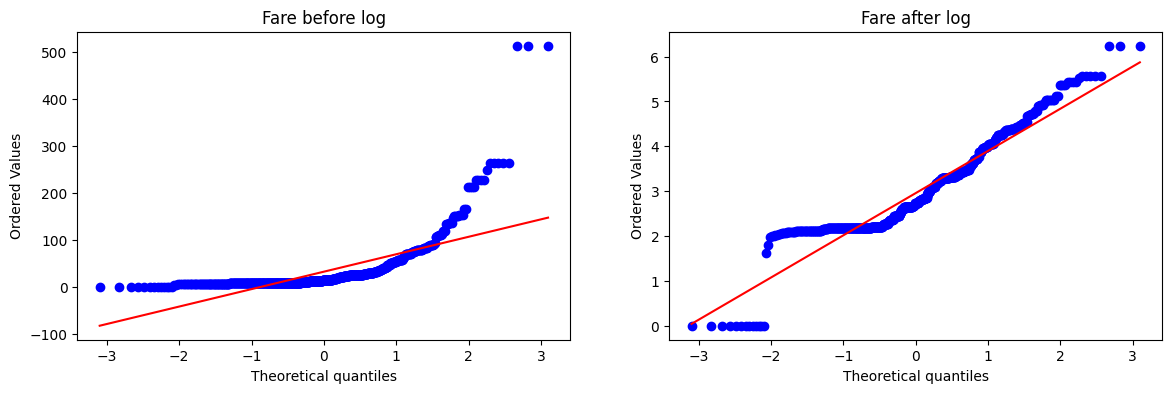

In [142]:
# Checking changes in distribution of age and fare after applying fn trf

plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare after log')

Text(0.5, 1.0, 'Age after log')

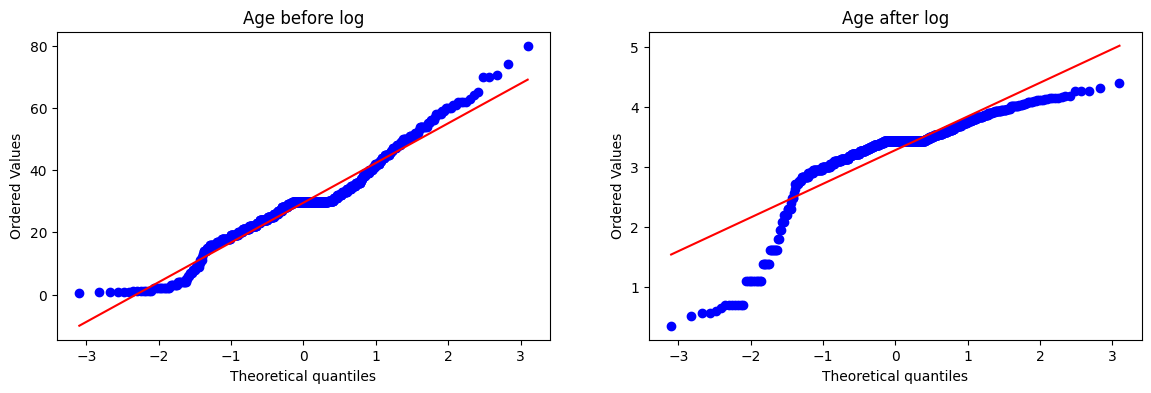

In [143]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Age after log')

In [144]:
# Fare distribution became more normal than before, but age became less normal than before, so now i will apply trf only to fare

In [145]:
col_Trf = ColumnTransformer([
    ('log', fn_trf, ['Fare'])
], remainder='passthrough')

X_train_transformed_2 = col_Trf.fit_transform(X_train)
X_test_transformed_2 = col_Trf.transform(X_test)

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

model1.fit(X_train_transformed_2, y_train)
model2.fit(X_train_transformed_2, y_train)

pred1 = model1.predict(X_test_transformed_2)
pred2 = model2.predict(X_test_transformed_2)

acc1 = accuracy_score(pred1, y_test)
acc2 = accuracy_score(pred2, y_test)

print(f'Accuracy (Logistic Reg) = {acc1*100 : .2f}')
print(f'Accuracy (Decision Tree) = {acc2*100 : .2f}')

Accuracy (Logistic Reg) =  67.04
Accuracy (Decision Tree) =  67.60


In [146]:
X_train_transformed_2

array([[ 3.38439026, 45.5       ],
       [ 2.63905733, 23.        ],
       [ 2.18885633, 32.        ],
       ...,
       [ 2.71524426, 41.        ],
       [ 4.79579055, 14.        ],
       [ 4.36038795, 21.        ]], shape=(712, 2))

In [147]:
X_transformed_2 = col_Trf.fit_transform(X)

model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

print('Logistic Reg', np.mean(cross_val_score(model1, X_transformed_2, y, scoring='accuracy', cv=10)))
print('Decision Tree', np.mean(cross_val_score(model2, X_transformed_2, y, scoring='accuracy', cv=10)))

Logistic Reg 0.6712609238451936
Decision Tree 0.6610861423220974


Text(0.5, 1.0, 'Fare after log')

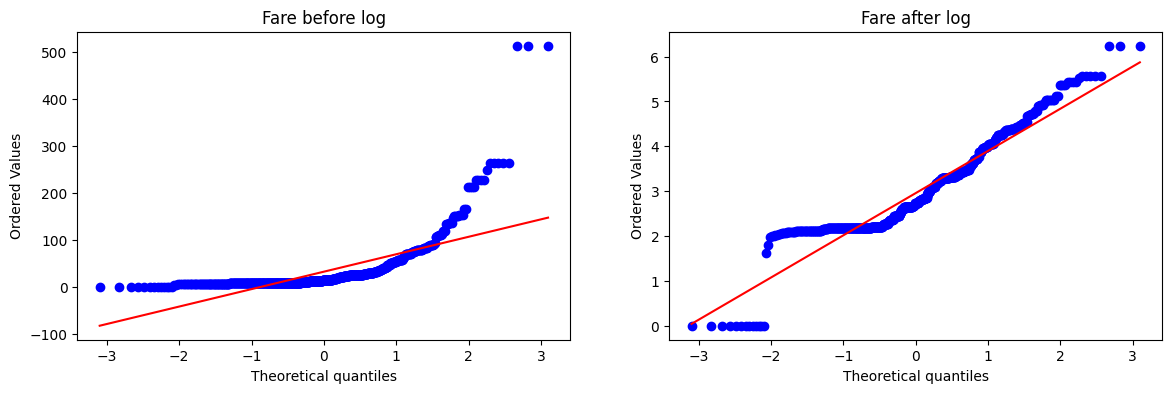

In [148]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_transformed_2[:, 0], dist='norm', plot=plt)
plt.title('Fare after log')

Text(0.5, 1.0, 'Age after log')

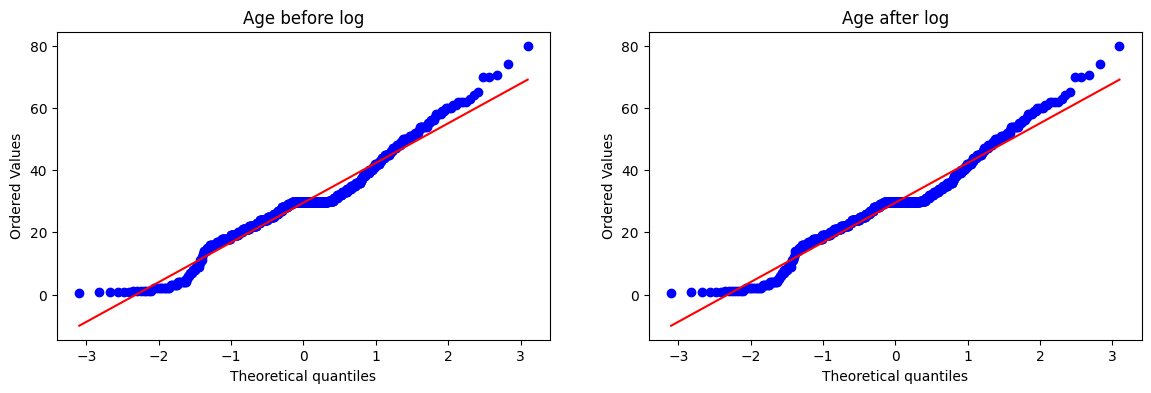

In [149]:
plt.figure(figsize=(14, 4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(X_train_transformed_2[:, 1], dist='norm', plot=plt)
plt.title('Age after log')

In [151]:
# Now applying other trf's to fare, no trf is applied to age since its already near to normal

In [152]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('transform',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6712609238451936


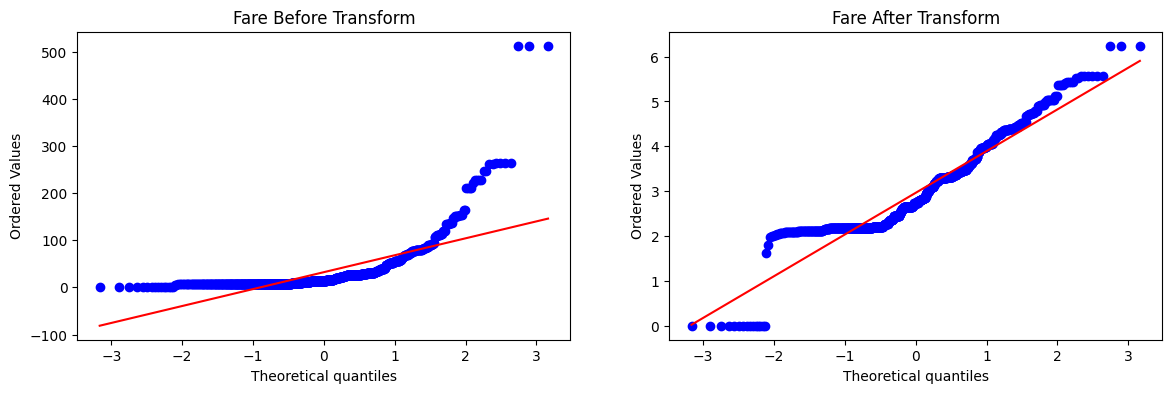

In [161]:
# apply_transform(lambda x: x)
# apply_transform(lambda x: x**2)
# apply_transform(lambda x: x**0.5)
# apply_transform(lambda x: x**3)
# apply_transform(lambda x: 1/(x + 0.0000000000000000000000000000000000000000000000001))
# apply_transform(np.sin)
apply_transform(np.log1p)